> ### Public copy — demo data
>
> The 2024 survey this project was built on belongs to the client and is not redistributable, so
> it is **not in this repository**. In its place, `data/raw/engagement_survey_2024.xlsx` is written
> by `scripts/make_demo_workbook.py`: the same sheet name, the same 22 columns and 42 rows, the
> same category headers, the same two 1-10 items and the same delta-from-company-mean encoding —
> and **entirely invented numbers**.
>
> So: the code, the method choices and the reasoning below are the originals. Every number, table
> and chart is computed from demo data, and every Phase 1 figure is badged **DEMO** instead of
> REAL. Where a passage describes what was actually found on the client's data it says so and
> points to the section of the accompanying report that carries the figures.
>
> `data.provenance` in `config/config.yaml` is the switch: set it to `real` once the client
> workbook is in place, and the badges change back.

# 03 — Phase 1: Multivariate Exploration

|  |  |
|---|---|
| **Purpose** | Do departments form *groups*? How many *dimensions* does the survey have? Which weak themes *matter*? |
| **Input** | `harmonised`, 19 department units x 34 items (treated in NB01) |
| **Outputs** | `fig03a`, `fig03b`, `fig04a`, `fig04b`, `fig04c` · `tab08a`–`tab08c`, `tab09`–`tab12` |
| **Evidence for essay** | §3.4 → **Figure 6** = `fig03a`, **Figure 7** = `fig03b`, **Figure 8** = `fig04a` · §3.5 → **Figure 9** = `fig04c` · §3.6 → the boundary · `fig04b` (PCA biplot) supports §3.4 but is not printed in the report |
| **Objectives** | RO1, RO3(a) |

Sections: **A** clustering · **B** PCA · **C** importance–performance · **D** composite index.
Throughout: ~19 aggregated units, so results are indicative; inference, reliability and factor
analysis are excluded by design (the argument of essay §3.6).

In [1]:
# Environment setup — package installed via `pip install -e .`; path fallback for direct runs
import sys
sys.path.insert(0, "../src")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, phase1, viz
from engagement.config import load_config, get_seed

# Some numpy/BLAS builds emit a spurious "divide by zero encountered in matmul"
# RuntimeWarning during ordinary matrix multiplication inside scikit-learn: the
# floating-point error flags are read after the BLAS call and may have been set
# by BLAS internals. It is suppressed here ONLY because the condition it would
# warn about is checked directly in code — phase1._prepare_matrix raises if any
# standardised value is non-finite (see the verification cell below).
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

cfg = load_config()
SEED = get_seed(cfg)
pd.set_option("display.max_colwidth", 90)
print(f"Config loaded · seed = {SEED}")

Config loaded · seed = 5496


In [2]:
raw = io.load_heatmap(cfg)
harmonised = quality.harmonise_scales(quality.reconstruct_absolute(io.tidy(raw, cfg)), cfg)

---
## A. Department clustering (run twice) · essay §3.4

| Run | Input | Question |
|---|---|---|
| **1 — LEVEL** | scores as reported | *Which* departments are struggling? |
| **2 — SHAPE** | each row centred on its own mean | *In what way* are they struggling? |

**Decision box**

| | |
|---|---|
| **What** | Ward hierarchical clustering of 19 units, both framings, `k` set by silhouette scan. |
| **Why** | Ward is deterministic and readable at n≈19. Level and shape imply different interventions, so both are reported. |
| **Why not a fixed k** | An assumed k cannot be defended. Singleton counts are reported too, isolating one department is outlier detection, not segmentation. Thresholds: Kaufman and Rousseeuw (1990). |
| **Rejected** | k-means unstable at this n; reserved for Phase 2 personas. |
| **Feeds** | `tab08a`–`tab08c`, `fig03a`, `fig03b` → essay §3.4 (Figures 6–7). |

In [3]:
# --- Verification before interpretation -------------------------------------
# Standardisation divides by each item's standard deviation. Confirm no item has
# zero variance and that both standardised matrices are finite, so that any
# numerical warning from the BLAS layer can be ruled out as spurious.
for mode in ("level", "shape"):
    m, z = phase1._prepare_matrix(harmonised, mode)
    print(f"{mode:>5}: shape={m.shape}  min item sd={m.std(ddof=0).min():.3f}  "
          f"all finite={np.isfinite(z).all()}  NaNs in input={int(m.isna().sum().sum())}")

# --- Selection criterion, both framings, before any solution is presented ----
scan_level = phase1.select_k(harmonised, cfg, mode="level")
scan_shape = phase1.select_k(harmonised, cfg, mode="shape")

scan = scan_level.join(scan_shape, lsuffix="_level", rsuffix="_shape")
print("\nSilhouette scan  (Kaufman & Rousseeuw 1990: >0.50 reasonable | 0.25-0.50 weak | <0.25 none)")
scan

level: shape=(19, 34)  min item sd=0.318  all finite=True  NaNs in input=0
shape: shape=(19, 34)  min item sd=0.194  all finite=True  NaNs in input=0

Silhouette scan  (Kaufman & Rousseeuw 1990: >0.50 reasonable | 0.25-0.50 weak | <0.25 none)


,silhouette_level,smallest_cluster_level,n_singletons_level,silhouette_shape,smallest_cluster_shape,n_singletons_shape
k,,,,,,
2,0.200,8,0,0.101,4,0
3,0.162,1,1,0.070,4,0
4,0.139,1,2,0.069,1,1
5,0.107,1,2,0.069,1,1
6,0.095,1,2,0.075,1,1


**Read:** two runs, one question each. The *level* run asks whether departments fall into groups
by how high they score overall. The *shape* run standardises each department first, so it asks
whether they group by *which* themes they are weak in — the only version that would justify the
word "archetype".

Judge both against the silhouette convention printed with the table (Kaufman & Rousseeuw, 1990:
> 0.50 reasonable structure, 0.25–0.50 weak and possibly artificial, < 0.25 no substantial
structure), and read the membership column alongside the score. A run that lifts its silhouette by
peeling off a single department has not found a segment; it has found an outlier.

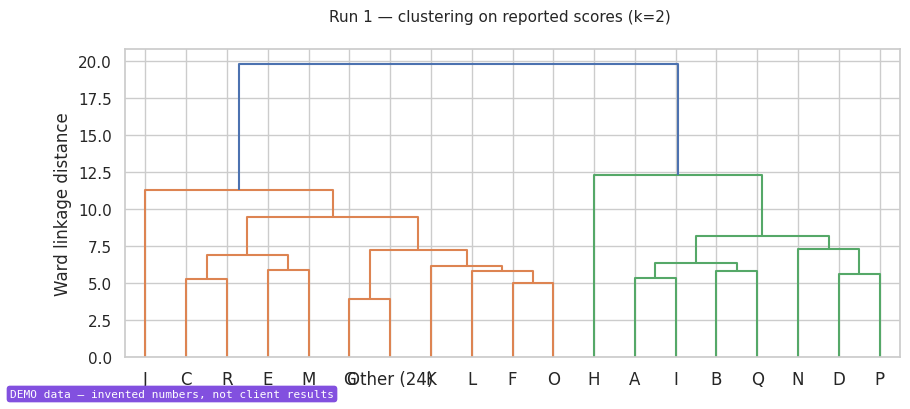

k selected by silhouette: 2
  cluster 1: ['C', 'E', 'F', 'G', 'J', 'K', 'L', 'M', 'O', 'Other (24)', 'R']
  cluster 2: ['A', 'B', 'D', 'H', 'I', 'N', 'P', 'Q']


In [4]:
from scipy.cluster.hierarchy import dendrogram

# ---- RUN 1: LEVEL ----------------------------------------------------------
assign_level, lnk_level = phase1.cluster_departments(harmonised, cfg, mode="level")
k_level = assign_level.iloc[:, 0].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(lnk_level, labels=assign_level.index.to_list(), ax=ax)
ax.set_ylabel("Ward linkage distance")
viz.save_figure(fig, "fig03a_dendrogram_level", cfg, "real",
                f"Run 1 — clustering on reported scores (k={k_level})")
plt.show()

print(f"k selected by silhouette: {k_level}")
for c in sorted(assign_level.iloc[:, 0].unique()):
    print(f"  cluster {c}: {sorted(assign_level[assign_level.iloc[:, 0] == c].index)}")

In [5]:
# What distinguishes the level clusters: absolute means (the LEVEL they sit at)
prof_level = phase1.cluster_profiles(harmonised, assign_level)
prof_level.T

cluster_level,1,2
Culture & Wellbeing,3.397,3.826
My role at Access Fintech,3.385,3.836
Work/Life Balance,3.176,3.584
Working for AccessFintech,3.550,4.021
Working with my Line Manager,3.397,4.054
Working with my Team,3.842,4.203
Working with the Executive Teams,2.697,3.042
Working with the Leadership Teams (Heads of Department),2.788,3.324
OVERALL,3.279,3.736
n_departments,11.000,8.000


In [6]:
# Same clusters, read as SHAPE: each theme minus that cluster's own overall mean.
# If the clusters differed only in level, every value here would be near zero.
phase1.cluster_profiles(harmonised, assign_level, relative=True).T

cluster_level,1,2
Culture & Wellbeing,0.118,0.089
My role at Access Fintech,0.106,0.100
Work/Life Balance,-0.103,-0.152
Working for AccessFintech,0.271,0.285
Working with my Line Manager,0.118,0.318
Working with my Team,0.563,0.467
Working with the Executive Teams,-0.582,-0.694
Working with the Leadership Teams (Heads of Department),-0.491,-0.412
n_departments,11.000,8.000


**Read:** compare the two cluster profiles column by column. If the clusters differ mainly in
overall *level* and barely in *which* themes are weak, then what the solution provides is a
ranking of who needs attention first — not a discovery of different kinds of department. It should
then be reported as the former, which is a much weaker claim and the only one the data supports.

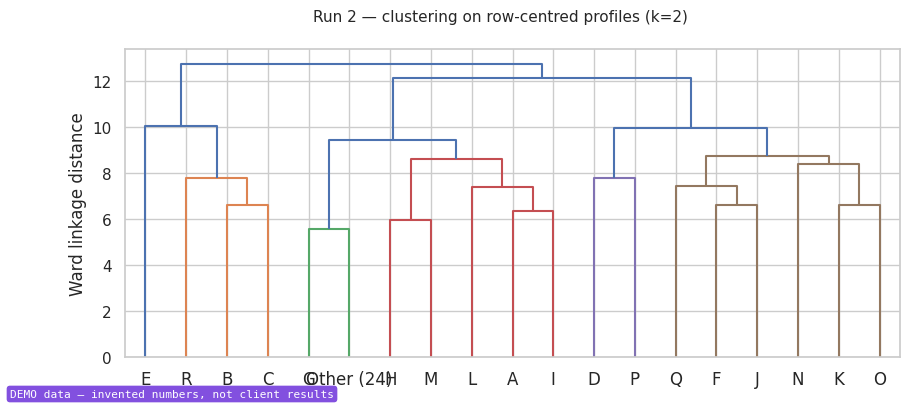

  cluster 1: ['B', 'C', 'E', 'R']
  cluster 2: ['A', 'D', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'Other (24)', 'P', 'Q']

Cross-tabulation of the two solutions:


cluster_shape,1,2
cluster_level,,
1,3,8
2,1,7


In [7]:
# ---- RUN 2: SHAPE (row-centred) --------------------------------------------
assign_shape, lnk_shape = phase1.cluster_departments(harmonised, cfg, mode="shape")
k_shape = assign_shape.iloc[:, 0].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(lnk_shape, labels=assign_shape.index.to_list(), ax=ax)
ax.set_ylabel("Ward linkage distance")
viz.save_figure(fig, "fig03b_dendrogram_shape", cfg, "real",
                f"Run 2 — clustering on row-centred profiles (k={k_shape})")
plt.show()

for c in sorted(assign_shape.iloc[:, 0].unique()):
    print(f"  cluster {c}: {sorted(assign_shape[assign_shape.iloc[:, 0] == c].index)}")

print("\nCross-tabulation of the two solutions:")
crosstab = phase1.compare_clusterings(assign_level, assign_shape)
crosstab

In [8]:
# Robustness check: does a profile structure appear once the outlier is removed?
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

outlier = assign_shape.iloc[:, 0].value_counts().idxmin()
outlier_dept = assign_shape[assign_shape.iloc[:, 0] == outlier].index.to_list()

m = phase1.department_matrix(harmonised).drop(index=outlier_dept)
z = StandardScaler().fit_transform(m.sub(m.mean(axis=1), axis=0))
lnk = linkage(pdist(z, metric="euclidean"), method="ward")

rows = []
for k in range(*[cfg["phase1"]["n_clusters_range"][0], cfg["phase1"]["n_clusters_range"][1] + 1]):
    lab = fcluster(lnk, t=k, criterion="maxclust")
    sizes = pd.Series(lab).value_counts()
    rows.append({"k": k, "silhouette": round(float(silhouette_score(z, lab)), 3),
                 "smallest_cluster": int(sizes.min()), "n_singletons": int((sizes == 1).sum())})

print(f"Shape clustering re-run with {outlier_dept} excluded:")
pd.DataFrame(rows).set_index("k")

Shape clustering re-run with ['B', 'C', 'E', 'R'] excluded:


,silhouette,smallest_cluster,n_singletons
k,,,
2,0.126,2,0
3,0.077,2,0
4,0.059,2,0
5,0.060,1,1
6,0.063,1,1


**Finding (essay §3.4).** On the client data the answer was negative: there were no distinct
kinds of department. Every grouping attempt either failed the silhouette convention or split off a
single department on its own, and departments differed in how high they scored overall rather than
in which themes they were weak in.

That is a *result*, not a dead end. It removes "segment the departments" from the recommendation
set, and it is one of the findings that redirects Phase 2 towards individual-level data. §3.4 of
the accompanying report carries the figures.

---
## B. Principal component analysis · essay §3.4 

Clustering asked whether departments fall into groups and found they do not. PCA asks a
different question: how many dimensions are in the 34 items, and what is each one made of?

**Decision box**

| | |
|---|---|
| **What** | PCA on the standardised 19 x 34 matrix, ≤5 components (config), each read from its item loadings. |
| **Why** | 34 items cannot be inspected raw. PCA compresses them while keeping loadings visible, so each axis can be named and defended. |
| **Boundary** | p (34) > n (19): components are unstable, so this is **structure-revealing, not confirmatory**. No rotation, no significance tests neither would be trustworthy here. |
| **Rejected** | Factor analysis is the right tool, but it needs individual-level data. Deferred to Phase 2; the gap is part of the RO4 argument. |
| **Feeds** | `fig04a`, `tab11`, `tab12` → essay §3.4 (**Figure 8**); `fig04b` retained as supporting evidence |

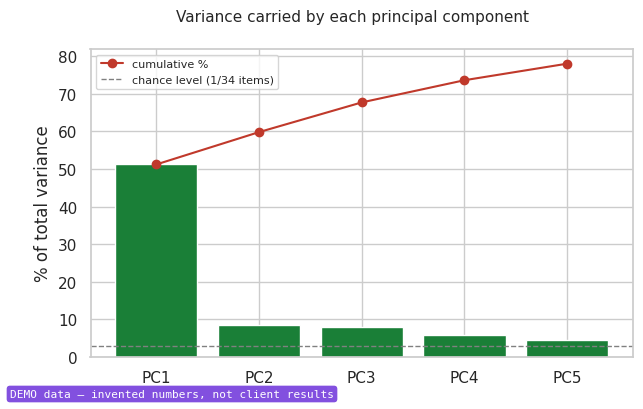

,explained_%,cumulative_%
PC1,51.2,51.2
PC2,8.5,59.8
PC3,7.9,67.7
PC4,5.9,73.6
PC5,4.4,78.0


In [9]:
pca = phase1.pca_departments(harmonised, cfg)
ev = pca["explained_variance_ratio"]

variance = pd.DataFrame({
    "explained_%": (ev * 100).round(1),
    "cumulative_%": (np.cumsum(ev) * 100).round(1),
}, index=[f"PC{i+1}" for i in range(len(ev))])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(variance.index, variance["explained_%"], color="#1a7f37")
ax.plot(variance.index, variance["cumulative_%"], marker="o", color="#c0392b", label="cumulative %")
ax.axhline(100 / harmonised[~harmonised["is_category_header"]]["item"].nunique(),
           ls="--", c="grey", lw=1, label="chance level (1/34 items)")
ax.set_ylabel("% of total variance"); ax.legend(fontsize=8)
viz.save_figure(fig, "fig04a_pca_scree", cfg, "real",
                "Variance carried by each principal component")
plt.show()

variance

**Read:** compare PC1's share of variance against the 1/34 ≈ 3% expected from 34 uninformative
items, and then look at the size of the drop to PC2. A dominant first component with a steep fall
behind it is the signature of one general factor with smaller structure underneath.

Only PC1 and PC2 are interpreted: at n ≈ 19 units later components are not separable from noise,
and `phase1.pca_max_components` in config caps the run well below n − 1 for exactly that reason.

In [10]:
# What is PC1? Read its loadings, then test the interpretation against an
# independent quantity: the simple composite index of overall engagement.
pc1 = pca["loadings"]["PC1"].sort_values()

print("PC1 — lowest loadings:");  print(pc1.head(4).round(3).to_string())
print("\nPC1 — highest loadings:"); print(pc1.tail(6).round(3).to_string())
print(f"\nShare of items loading positively on PC1: "
      f"{(pca['loadings']['PC1'] > 0).mean():.0%}")

composite = phase1.composite_index(harmonised)["composite_index"].drop("Company")
r = pca["scores"]["PC1"].corr(composite)
print(f"Correlation of PC1 score with the composite engagement index: r = {r:.3f}")

PC1 — lowest loadings:
item
On a scale of one to ten, how well are you able to balance your work and personal commitments?    0.116
Me and my team members contribute to the success of our team and the success of the company.      0.121
I think my work environment reflects the company culture.                                         0.136
I trust the Executive team to lead the business to success.                                       0.140

PC1 — highest loadings:
item
How happy are you at AccessFintech on a scale of 1 to 10?        0.192
My work is appreciated by my direct manager.                     0.192
I am optimistic about Access Fintech's long-term success.        0.199
I would recommend AFT to my friends.                             0.203
I feel the amount of work assigned to me is manageable           0.203
I feel the HR team at Access Fintech care about my wellbeing.    0.205

Share of items loading positively on PC1: 100%
Correlation of PC1 score with the composite engageme

**Read:** two checks decide whether PC1 is a *topic* or a *mood*. First the loadings — if nearly
all items load positively and the strongest are global-sentiment items, PC1 is not about any one
subject. Second, and this is the part worth copying: the interpretation is **tested rather than
asserted**, by correlating PC1 against the composite favourability index computed independently in
section D. A correlation close to 1 means the two are the same quantity reached by two different
routes, and that is the halo evidence.

In [11]:
# What is PC2? Unlike PC1 it has two opposing ends — read both.
pc2 = pca["loadings"]["PC2"].sort_values()

print("PC2 — negative end:"); print(pc2.head(5).round(3).to_string())
print("\nPC2 — positive end:"); print(pc2.tail(5).round(3).to_string())

PC2 — negative end:
item
The HR team are attentive, involved and helpful, I feel like I have someone to turn to.                          -0.310
I feel comfortable sharing my ideas at work with peers and management.                                           -0.281
I feel Accessfintech's culture is collaborative and empowering.                                                  -0.247
The day-to-day decisions here demonstrate that we continuously learn from experiences and aim for improvement.   -0.210
I feel the HR team at Access Fintech care about my wellbeing.                                                    -0.195

PC2 — positive end:
item
The executive team contributes to a positive work culture.                                                         0.246
AFT places great importance on the growth and development of its people.                                           0.257
I am recognized for my accomplishments and contributions to the company.                                   

**Read:** PC2 is read from its two ends. A component that puts the **proximal** experience (own
manager, own role) at one end and the **distal** one (leadership, executive communication) at the
other is not measuring either of them — it is measuring the *gap* between them.

Cross-check it against the line-manager ↔ leadership correlation from NB02: if those two themes
were near-independent there, then a proximal–distal axis here is the same fact seen a second time
by a different method.

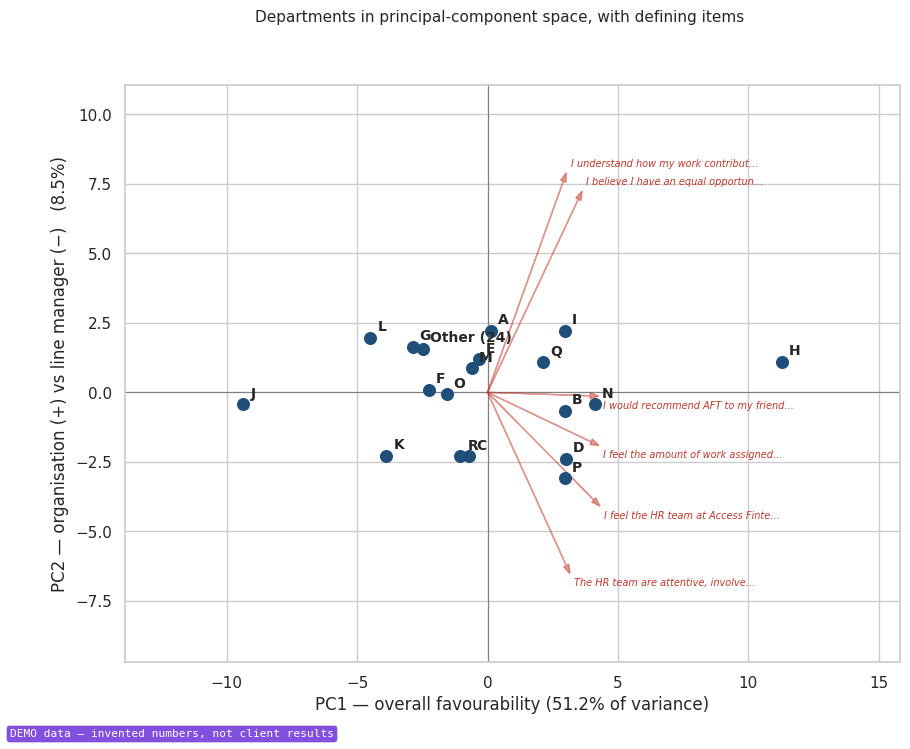

,PC1,PC2
department,,
J,-9.36,-0.43
L,-4.49,1.96
K,-3.87,-2.29
G,-2.87,1.64
Other (24),-2.49,1.56
F,-2.25,0.10
O,-1.57,-0.07
R,-1.04,-2.30
C,-0.71,-2.29


In [12]:
# Where does each department sit? Biplot: department scores + the items that
# define each axis. Departments far from the origin are distinctive.
s = pca["scores"]
load = pca["loadings"]
top_items = pd.concat([load["PC1"].abs().nlargest(3), load["PC2"].abs().nlargest(3)]).index.unique()
scale = 0.7 * s[["PC1", "PC2"]].abs().max().max() / load.loc[top_items, ["PC1", "PC2"]].abs().max().max()

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.axhline(0, c="grey", lw=0.8); ax.axvline(0, c="grey", lw=0.8)
ax.scatter(s["PC1"], s["PC2"], s=70, color="#1f4e79", zorder=3)
for d, r_ in s.iterrows():
    ax.annotate(d, (r_["PC1"], r_["PC2"]), fontsize=10, fontweight="bold",
                xytext=(5, 5), textcoords="offset points", zorder=4)

for it in top_items:
    x, y = load.loc[it, "PC1"] * scale, load.loc[it, "PC2"] * scale
    ax.arrow(0, 0, x, y, color="#c0392b", alpha=0.5,
             head_width=0.22, length_includes_head=True, zorder=2)
    ax.annotate(it[:34] + ("…" if len(it) > 34 else ""), (x, y), color="#c0392b",
                fontsize=7, style="italic", zorder=4,
                ha="left" if x >= 0 else "right",
                va="bottom" if y >= 0 else "top",
                xytext=(3 if x >= 0 else -3, 3 if y >= 0 else -3),
                textcoords="offset points")

ax.margins(0.22)
ax.set_xlabel(f"PC1 — overall favourability ({ev[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 — organisation (+) vs line manager (−)   ({ev[1]:.1%})")
viz.save_figure(fig, "fig04b_pca_biplot", cfg, "real",
                "Departments in principal-component space, with defining items")
plt.show()

s[["PC1", "PC2"]].round(2).sort_values("PC1")

**Read:** the horizontal axis reproduces overall favourability, so it should reorder the
departments much as section A did — that is a sanity check, not a finding.

The vertical axis carries what clustering could not. Two departments can both sit low overall and
still fall at **opposite ends of PC2**: one with a manager problem, one with an
organisational-communication problem. Same symptom at theme level, different interventions,
different owners. Note carefully what this licenses — named individual cases, not segments. The
client's two cases are discussed in §3.4 of the accompanying report.

In [13]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"])
variance.to_csv(t / "tab11_pca_variance.csv")
pca["loadings"][["PC1", "PC2"]].round(3).to_csv(t / "tab12_pca_loadings.csv")
print("PCA tables written (tab11, tab12)")

PCA tables written (tab11, tab12)


---
## C. Importance–Performance: "which weak areas matter?" · essay §3.5

A low score justifies spending only if the theme is associated with how favourably a department
answers overall. This map puts both quantities together (Martilla and James, 1977).

**Decision box**

| | |
|---|---|
| **What** | Theme correlation with the outcome anchors (importance) x company theme mean (performance), split at the medians. |
| **Why** | The most decision-useful technique aggregated data admits: two descriptive quantities become a ranked action list. |
| **Why these two anchors** | They measure the overall state, while the other 32 questions measure its antecedents. No other item in the survey plays that role. |
| **Circularity fix** | Both anchors sit inside 'Working for AccessFintech', so scoring that theme from items it is then correlated against is circular (0.92). Themes are now scored from **non-anchor** items; `importance_naive` keeps the old value so the −0.12 correction is auditable. |
| **Rejected** | Calling these *drivers*, an association over ~19 units is not a driver model. That is Phase 2. |
| **Feeds** | `tab09`, `fig04c` → essay §3.5 (**Figure 9**); priority interventions in §6.2 |

In [14]:
ipma = phase1.ipma(harmonised, cfg)

adj = ipma.index[ipma["anchor_adjusted"]].tolist()
print(f"anchor-corrected theme : {adj}")
print(f"correction size        : {ipma.loc[adj, 'importance_shift'].iloc[0]:+.2f}  "
      f"({ipma.loc[adj, 'importance_naive'].iloc[0]:.2f} -> "
      f"{ipma.loc[adj, 'importance'].iloc[0]:.2f})")
print(f"priority quadrant      : {ipma.index[ipma['priority']].tolist()}")
print(f"importance range       : {ipma['importance'].min():.2f} to {ipma['importance'].max():.2f}")
print(f"performance range      : {ipma['performance'].min():.2f} to {ipma['performance'].max():.2f}"
      f"  (span {ipma['performance'].max() - ipma['performance'].min():.2f})")

ipma.round(3)

anchor-corrected theme : ['Working for AccessFintech']
correction size        : -0.09  (0.94 -> 0.85)
priority quadrant      : ['Culture & Wellbeing', 'Working with the Executive Teams']
importance range       : 0.53 to 0.85
performance range      : 3.07 to 4.20  (span 1.13)


,importance,importance_naive,performance,anchor_adjusted,importance_shift,priority
category,,,,,,
Culture & Wellbeing,0.718,0.718,3.810,False,0.00,True
Working with the Executive Teams,0.685,0.685,3.073,False,0.00,True
Working for AccessFintech,0.854,0.944,3.997,True,-0.09,False
Working with my Team,0.773,0.773,4.200,False,0.00,False
My role at Access Fintech,0.676,0.676,3.823,False,0.00,False
Working with the Leadership Teams (Heads of Department),0.636,0.636,3.263,False,0.00,False
Work/Life Balance,0.618,0.618,3.640,False,0.00,False
Working with my Line Manager,0.527,0.527,3.884,False,0.00,False


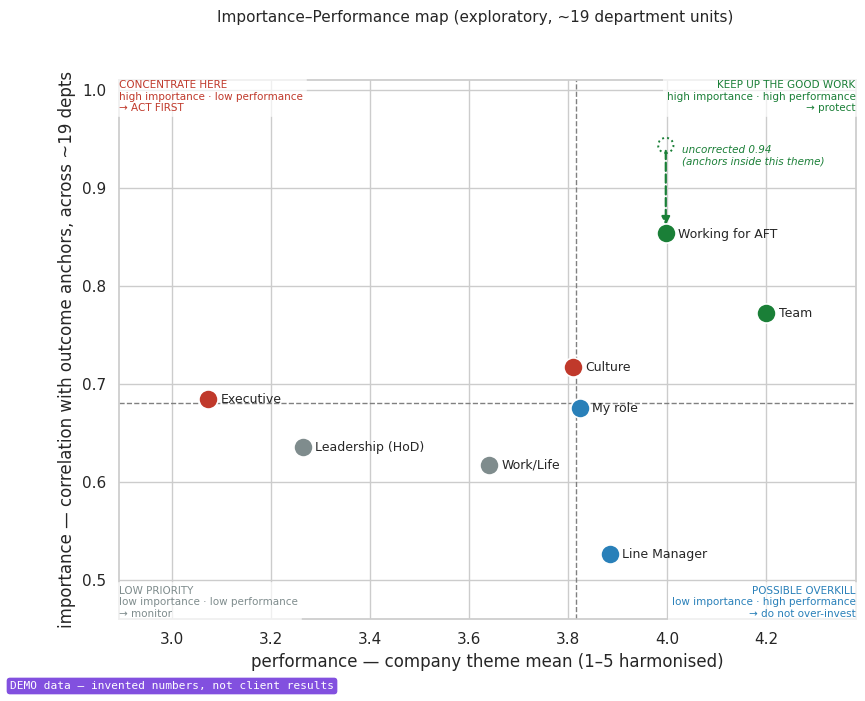

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 7))
viz.ipma_map(ipma, ax=ax)
viz.save_figure(fig, "fig04c_ipma_map", cfg, "real",
                "Importance–Performance map (exploratory, ~19 department units)")
plt.show()

**Read (essay §3.5):** the map is a prioritisation aid, and three cautions travel with it.

1. The importance axis is a correlation-based proxy computed at department level from ~19 units, so
   it is weak by construction.
2. The performance axis spans a fraction of a scale point, so small differences can move a theme
   between quadrants.
3. The anchor items used to define importance sit *inside* one of the themes being scored, which
   inflates that theme. The arrow shows this circularity correction applied to scale — the theme
   moves, and what matters is whether it stays in the same quadrant. A conclusion that survives
   its own correction is one you can report.

A theme scoring *lowest* on importance is usually one that does not discriminate between
departments, rather than one that does not matter — a property of the proxy, not of the theme.
Reported as exploratory throughout. The client's quadrant assignments are in §3.5 of the
accompanying report.

---
## D. Composite index · Evidence for Phase 1

**Decision box**

| | |
|---|---|
| **What** | One score per department: mean of its eight theme scores, equal-weighted by default (`weights=` available). |
| **Why** | Equal weighting is the transparent baseline (OECD/JRC, 2008); with strongly inter-correlated themes, unit weights perform near-optimally (Wainer, 1976; Dawes, 1979). |
| **Rejected** | An opaque weighted index, any weight set here would rest on evidence this dataset lacks. |
| **Feeds** | `tab10`; the independent check on PC1 above, and the department ranking behind essay §3.2. |

In [16]:
comp = phase1.composite_index(harmonised)

print(f"company composite        : {comp.loc['Company', 'composite_index']:.3f}")
print(f"highest                  : {comp.index[0]} {comp['composite_index'].iloc[0]:.3f}")
print(f"lowest                   : {comp.index[-1]} {comp['composite_index'].iloc[-1]:.3f}")
print(f"spread across departments: "
      f"{comp['composite_index'].iloc[0] - comp['composite_index'].iloc[-1]:.3f}")
print(f"units below the company  : {int((comp['vs_company'] < 0).sum())} of {len(comp) - 1}")

comp

company composite        : 3.711
highest                  : H 4.304
lowest                   : J 2.757
spread across departments: 1.547
units below the company  : 15 of 19


,composite_index,vs_company
department,,
H,4.304,0.593
N,3.775,0.064
B,3.731,0.020
D,3.720,0.009
Company,3.711,0.000
I,3.686,-0.025
P,3.635,-0.076
Q,3.577,-0.134
C,3.470,-0.241


**Read:** the composite index does two jobs. It gives one defensible number per department for
the client to act on, and it is the independent check on PC1 used in section B.

The comparison to make is between the spread *across departments* and the spread *across themes*.
When the first is clearly the larger, the actionable variation lies between departments rather
than between topics — which is why the report leads on departmental benchmarking rather than on
theme ranking. Figures for the client data are in §3.2 and §3.4 of the accompanying report.

In [17]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"])

scan.to_csv(t / "tab08a_cluster_k_selection.csv")
assign_level.join(assign_shape).to_csv(t / "tab08b_department_clusters_both_runs.csv")
phase1.cluster_profiles(harmonised, assign_level).to_csv(t / "tab08c_cluster_profiles.csv")
assign_level.to_csv(t / "tab08_department_clusters.csv")   # kept for the pipeline/app
ipma.to_csv(t / "tab09_ipma.csv")
comp.to_csv(t / "tab10_composite_index.csv")
print("tables tab08–tab10 written")

tables tab08–tab10 written


---
## Handover

Phase 1 delivers: theme profile (§3.1), department benchmark (§3.2), priority-risk items (§3.3),
an evidenced statement of what groupings the data supports (§3.4), and a priority quadrant (§3.5).

It cannot deliver drivers, individual risk scores, trends, demographic segments or archetypes,
each traceable to a missing data element rather than to method. That is essay §3.6 and the design
brief for the synthetic demonstration.

**Next:** `04_synthetic_generation_validation.ipynb`.

---
## References

Dawes, R.M. (1979) 'The robust beauty of improper linear models in decision making',
*American Psychologist*, 34(7), pp. 571–582. doi:10.1037/0003-066X.34.7.571.

Kaufman, L. and Rousseeuw, P.J. (1990) *Finding groups in data: an introduction to cluster
analysis*. New York: Wiley.

Martilla, J.A. and James, J.C. (1977) 'Importance-performance analysis', *Journal of
Marketing*, 41(1), pp. 77–79. doi:10.1177/002224297704100112.

OECD and Joint Research Centre (2008) *Handbook on constructing composite indicators:
methodology and user guide*. Paris: OECD Publishing.

Wainer, H. (1976) 'Estimating coefficients in linear models: it don't make no nevermind',
*Psychological Bulletin*, 83(2), pp. 213–217.